In [1]:
# Fix macOS SSL certificate verify failed saat download pretrained weights (python.org build tidak
# otomatis trust ke macOS keychain). PENTING: setelah nambah/ubah cell ini, restart kernel dulu
# (bukan cuma re-run cell ini) supaya tidak ada SSL context lama yang sudah kepakai di proses kernel
# sebelum fix ini sempat jalan.
import os
import ssl
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())


In [ ]:
import os
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as F
import random

from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torchmetrics.detection.mean_ap import MeanAveragePrecision

from tqdm.notebook import tqdm  
import time


## Section 1: Persiapan Data (OMNI Dataset)
Tahap ini mencakup: import library, load anotasi COCO, validasi bounding box, cek distribusi kelas, dan split data.


In [3]:
DATA_ROOT = Path("/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/omni_coco")
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
SPLITS = ["train", "val", "test"]

IMAGES_DIRS = {split: DATA_ROOT / split for split in SPLITS}
ANNOTATION_FILES = {split: ANNOTATIONS_DIR / f"instances_{split}.json" for split in SPLITS}

for split in SPLITS:
    assert IMAGES_DIRS[split].exists(), f"Folder gambar tidak ditemukan: {IMAGES_DIRS[split]}"
    assert ANNOTATION_FILES[split].exists(), f"File anotasi tidak ditemukan: {ANNOTATION_FILES[split]}"


In [4]:
coco_data = {}
for split in SPLITS:
    with open(ANNOTATION_FILES[split], "r") as f:
        coco_data[split] = json.load(f)

    d = coco_data[split]
    print(f"--- {split} ---")
    print("Keys utama:", d.keys())
    print("Jumlah images:", len(d["images"]))
    print("Jumlah annotations:", len(d["annotations"]))
    print("Jumlah categories:", len(d["categories"]))


--- train ---
Keys utama: dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
Jumlah images: 2481
Jumlah annotations: 36449
Jumlah categories: 10
--- val ---
Keys utama: dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
Jumlah images: 857
Jumlah annotations: 12482
Jumlah categories: 10
--- test ---
Keys utama: dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
Jumlah images: 828
Jumlah annotations: 12207
Jumlah categories: 10


In [5]:
print("Contoh image entry:")
print(coco_data["train"]["images"][0])

print("\nContoh annotation entry:")
print(coco_data["train"]["annotations"][0])

print("\nContoh category entry:")
print(coco_data["train"]["categories"])


Contoh image entry:
{'id': 201801201807301, 'file_name': '201801201807301.JPG', 'width': 512, 'height': 341, 'subfolder1': '2018.01', 'subfolder2': '2018.07.30'}

Contoh annotation entry:
{'id': 1, 'image_id': 201801201807301, 'category_id': 2, 'bbox': [119.0, 122.0, 44.0, 62.0], 'area': 2728.0, 'segmentation': [], 'iscrowd': 0}

Contoh category entry:
[{'id': 1, 'supercategory': 'your_super_category', 'name': 'HT'}, {'id': 2, 'supercategory': 'your_super_category', 'name': 'TT'}, {'id': 3, 'supercategory': 'your_super_category', 'name': 'DO'}, {'id': 4, 'supercategory': 'your_super_category', 'name': 'IOA'}, {'id': 5, 'supercategory': 'your_super_category', 'name': 'TE'}, {'id': 6, 'supercategory': 'your_super_category', 'name': 'CFOA'}, {'id': 7, 'supercategory': 'your_super_category', 'name': 'TM'}, {'id': 8, 'supercategory': 'your_super_category', 'name': 'MR'}, {'id': 9, 'supercategory': 'your_super_category', 'name': 'OB'}, {'id': 10, 'supercategory': 'your_super_category', 'name

In [6]:
for split in SPLITS:
    d = coco_data[split]
    print(f"[{split}] images={len(d['images'])}, annotations={len(d['annotations'])}, categories={len(d['categories'])}")

[train] images=2481, annotations=36449, categories=10
[val] images=857, annotations=12482, categories=10
[test] images=828, annotations=12207, categories=10


In [7]:
# Mapping category_id
categories = coco_data["train"]["categories"]

category_id_to_name = {cat["id"]: cat["name"] for cat in categories}
category_name_to_id = {v: k for k, v in category_id_to_name.items()}

print(category_id_to_name)
assert min(category_id_to_name.keys()) == 1, "category_id harusnya mulai dari 1, bukan 0"

{1: 'HT', 2: 'TT', 3: 'DO', 4: 'IOA', 5: 'TE', 6: 'CFOA', 7: 'TM', 8: 'MR', 9: 'OB', 10: 'FOD'}


In [8]:
#helper untuk bangun path gambar lengkap dari image record

def get_image_path(split: str, image_record: dict) -> Path:
    """
    Path fisik gambar mengikuti struktur:
    Dataset/omni_coco/{split}/<subfolder1>/<subfolder2>/<file_name>
    """
    return IMAGES_DIRS[split] / image_record["subfolder1"] / image_record["subfolder2"] / image_record["file_name"]


# quick test pakai 1 record
sample_record = coco_data["train"]["images"][0]
sample_path = get_image_path("train", sample_record)
print(sample_path)
print("File ada?", sample_path.exists())

/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/omni_coco/train/2018.01/2018.07.30/201801201807301.JPG
File ada? True


In [9]:
# cek split

missing_files = {split: [] for split in SPLITS}

for split in SPLITS:
    for img_record in coco_data[split]["images"]:
        path = get_image_path(split, img_record)
        if not path.exists():
            missing_files[split].append(img_record)

for split in SPLITS:
    print(f"[{split}] file hilang: {len(missing_files[split])} dari {len(coco_data[split]['images'])}")

[train] file hilang: 0 dari 2481
[val] file hilang: 0 dari 857
[test] file hilang: 0 dari 828


In [10]:
# cek ukuran gambar seragam

sizes = set()
for split in SPLITS:
    for img_record in coco_data[split]["images"]:
        sizes.add((img_record["width"], img_record["height"]))

print("Ukuran unik yang ditemukan:", sizes)
assert sizes == {(512, 341)}, "Ada gambar dengan ukuran di luar 512x341, cek data ini"


Ukuran unik yang ditemukan: {(512, 341)}


      train   val  test  total
HT    23011  7395  7638  38044
FOD    5727  2139  1818   9684
IOA    1771   855   787   3413
TT     2020   684   660   3364
OB     1376   408   432   2216
MR      930   343   331   1604
DO      546   272   196   1014
TE      602   214   195   1011
CFOA    381   130    97    608
TM       85    42    53    180


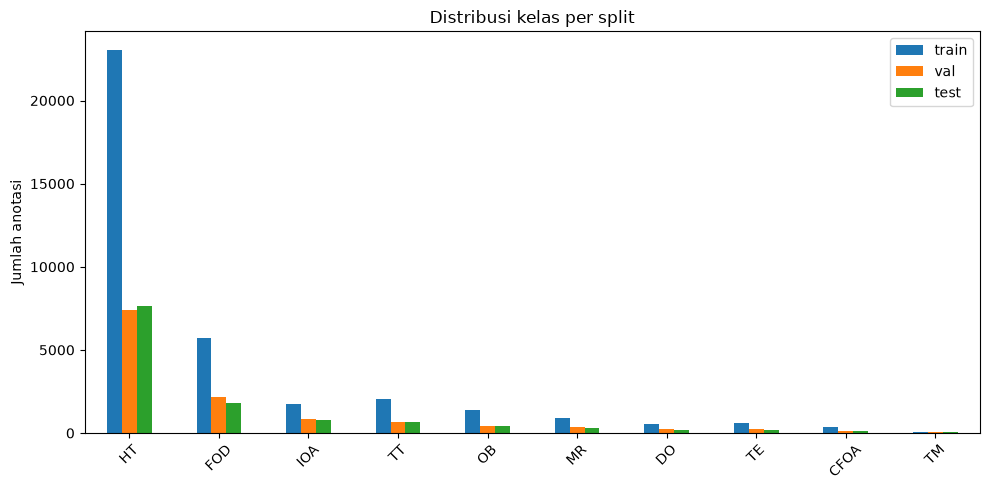

In [11]:
#cek distribusi jumlah anotasi per kelas, per split

class_dist = {}

for split in SPLITS:
    counts = Counter(
        category_id_to_name[ann["category_id"]] for ann in coco_data[split]["annotations"]
    )
    class_dist[split] = counts

df_dist = pd.DataFrame(class_dist).fillna(0).astype(int)
df_dist["total"] = df_dist.sum(axis=1)
df_dist = df_dist.sort_values("total", ascending=False)
print(df_dist)

df_dist[SPLITS].plot(kind="bar", figsize=(10, 5))
plt.title("Distribusi kelas per split")
plt.ylabel("Jumlah anotasi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# cek validasi bbound box per split

invalid_boxes = {split: [] for split in SPLITS}

for split in SPLITS:
    image_id_to_size = {img["id"]: (img["width"], img["height"]) for img in coco_data[split]["images"]}

    for ann in coco_data[split]["annotations"]:
        x, y, w, h = ann["bbox"]
        img_w, img_h = image_id_to_size[ann["image_id"]]

        is_invalid = (
            w <= 0 or h <= 0
            or x < 0 or y < 0
            or (x + w) > img_w
            or (y + h) > img_h
        )
        if is_invalid:
            invalid_boxes[split].append(ann)

for split in SPLITS:
    print(f"[{split}] bbox bermasalah: {len(invalid_boxes[split])} dari {len(coco_data[split]['annotations'])}")

[train] bbox bermasalah: 2 dari 36449
[val] bbox bermasalah: 2 dari 12482
[test] bbox bermasalah: 0 dari 12207


In [13]:
#verifikasi leakage

case_ids_per_split = {
    split: set(img["subfolder1"] for img in coco_data[split]["images"])
    for split in SPLITS
}

overlap_train_val = case_ids_per_split["train"] & case_ids_per_split["val"]
overlap_train_test = case_ids_per_split["train"] & case_ids_per_split["test"]
overlap_val_test = case_ids_per_split["val"] & case_ids_per_split["test"]

print("Overlap train-val:", len(overlap_train_val))
print("Overlap train-test:", len(overlap_train_test))
print("Overlap val-test:", len(overlap_val_test))

assert not overlap_train_val and not overlap_train_test and not overlap_val_test, \
    "Ada case_id (subfolder1) yang bocor antar split!"

Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


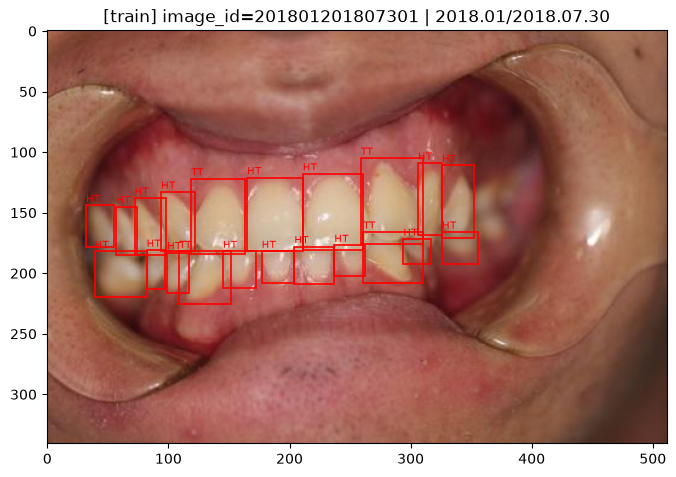

In [14]:
# visualisasi beberapa gambar dengan bounding box

def show_sample(split: str, image_id: int):
    img_record = next(img for img in coco_data[split]["images"] if img["id"] == image_id)
    img_path = get_image_path(split, img_record)
    img = Image.open(img_path)

    anns = [a for a in coco_data[split]["annotations"] if a["image_id"] == image_id]

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img)

    for ann in anns:
        x, y, w, h = ann["bbox"]
        label = category_id_to_name[ann["category_id"]]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 3, label, color="red", fontsize=7)

    plt.title(f"[{split}] image_id={image_id} | {img_record['subfolder1']}/{img_record['subfolder2']}")
    plt.show()


sample_id = coco_data["train"]["images"][0]["id"]
show_sample("train", sample_id)

In [15]:
# summary

summary = {
    "split": SPLITS,
    "n_images": [len(coco_data[s]["images"]) for s in SPLITS],
    "n_annotations": [len(coco_data[s]["annotations"]) for s in SPLITS],
    "n_missing_files": [len(missing_files[s]) for s in SPLITS],
    "n_invalid_boxes": [len(invalid_boxes[s]) for s in SPLITS],
}
pd.DataFrame(summary)

,split,n_images,n_annotations,n_missing_files,n_invalid_boxes
0,train,2481,36449,0,2
1,val,857,12482,0,2
2,test,828,12207,0,0


In [16]:
#cek box invalid

def inspect_invalid_boxes(split: str):
    image_id_to_size = {img["id"]: (img["width"], img["height"]) for img in coco_data[split]["images"]}

    for ann in invalid_boxes[split]:
        x, y, w, h = ann["bbox"]
        img_w, img_h = image_id_to_size[ann["image_id"]]
        label = category_id_to_name[ann["category_id"]]
        print(
            f"[{split}] ann_id={ann['id']} image_id={ann['image_id']} label={label}\n"
            f"  bbox=[x={x}, y={y}, w={w}, h={h}]  img_size=({img_w}, {img_h})\n"
            f"  x+w={x+w}  y+h={y+h}\n"
        )

inspect_invalid_boxes("train")
inspect_invalid_boxes("val")


[train] ann_id=10135 image_id=201882201812125 label=HT
  bbox=[x=462.0, y=186.0, w=0.0, h=0.0]  img_size=(512, 341)
  x+w=462.0  y+h=186.0

[train] ann_id=10225 image_id=201883201809131 label=HT
  bbox=[x=490.0, y=220.0, w=0.0, h=0.0]  img_size=(512, 341)
  x+w=490.0  y+h=220.0

[val] ann_id=2803 image_id=201869201808305 label=HT
  bbox=[x=271.0, y=263.0, w=0.0, h=0.0]  img_size=(512, 341)
  x+w=271.0  y+h=263.0

[val] ann_id=6610 image_id=202128202310081 label=IOA
  bbox=[x=471.0, y=180.0, w=0.0, h=2.0]  img_size=(512, 341)
  x+w=471.0  y+h=182.0



Box dengan lebar/tinggi nol itu bukan bounding box valid sama sekali, kemungkinan besar human error saat anotasi di Makesense.ai (klik tanpa drag, atau titik yang ke-submit tanpa area). Ini harus dibuang, tidak bisa di-clip karena memang tidak ada area untuk diselamatkan.

In [17]:
# drop invalid boxes from coco_data

def drop_invalid_annotations(split: str):
    invalid_ann_ids = {ann["id"] for ann in invalid_boxes[split]}

    original_count = len(coco_data[split]["annotations"])
    coco_data[split]["annotations"] = [
        ann for ann in coco_data[split]["annotations"]
        if ann["id"] not in invalid_ann_ids
    ]
    new_count = len(coco_data[split]["annotations"])

    print(f"[{split}] annotations: {original_count} -> {new_count} (dibuang {original_count - new_count})")


for split in SPLITS:
    if invalid_boxes[split]:
        drop_invalid_annotations(split)

[train] annotations: 36449 -> 36447 (dibuang 2)
[val] annotations: 12482 -> 12480 (dibuang 2)


In [18]:
# revalidasi
invalid_boxes_recheck = {split: [] for split in SPLITS}

for split in SPLITS:
    image_id_to_size = {img["id"]: (img["width"], img["height"]) for img in coco_data[split]["images"]}

    for ann in coco_data[split]["annotations"]:
        x, y, w, h = ann["bbox"]
        img_w, img_h = image_id_to_size[ann["image_id"]]

        is_invalid = (
            w <= 0 or h <= 0
            or x < 0 or y < 0
            or (x + w) > img_w
            or (y + h) > img_h
        )
        if is_invalid:
            invalid_boxes_recheck[split].append(ann)

for split in SPLITS:
    print(f"[{split}] bbox bermasalah setelah cleanup: {len(invalid_boxes_recheck[split])}")

# update variabel invalid_boxes supaya konsisten dipakai di cell summary (Cell 12) kalau dijalankan ulang
invalid_boxes = invalid_boxes_recheck

[train] bbox bermasalah setelah cleanup: 0
[val] bbox bermasalah setelah cleanup: 0
[test] bbox bermasalah setelah cleanup: 0


## Section 2: Dataset & DataLoader

Membangun custom `Dataset` untuk format COCO nested folder (subfolder1/subfolder2),
transform (resize + flip + normalize sesuai paper), custom `collate_fn`,
dan `DataLoader` untuk train/val/test.

In [19]:
# Bangun index per-gambar: image_id -> list of annotations

def build_image_to_anns_index(split: str):
    index = {}
    for ann in coco_data[split]["annotations"]:
        index.setdefault(ann["image_id"], []).append(ann)
    return index

image_to_anns = {split: build_image_to_anns_index(split) for split in SPLITS}

# sanity check
sample_img_id = coco_data["train"]["images"][0]["id"]
print(f"Jumlah anotasi untuk image_id {sample_img_id}:", len(image_to_anns["train"].get(sample_img_id, [])))

Jumlah anotasi untuk image_id 201801201807301: 21


In [20]:
# Transform: fungsi resize + flip + normalize

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

TARGET_LONG_SIDE = 1333
TARGET_SHORT_SIDE = 800


def resize_image_and_boxes(image, boxes, orig_w, orig_h):
    """
    Resize dengan mempertahankan aspect ratio, sisi panjang <= TARGET_LONG_SIDE,
    sisi pendek <= TARGET_SHORT_SIDE, mengikuti setup di paper.
    Karena gambar OMNI landscape (512x341), sisi lebar jadi acuan "long side".
    """
    scale = min(TARGET_LONG_SIDE / max(orig_w, orig_h), TARGET_SHORT_SIDE / min(orig_w, orig_h))
    new_w, new_h = int(round(orig_w * scale)), int(round(orig_h * scale))

    image = image.resize((new_w, new_h), Image.BILINEAR)

    if len(boxes) > 0:
        boxes = boxes.clone()
        boxes[:, [0, 2]] *= scale  # x_min, x_max
        boxes[:, [1, 3]] *= scale  # y_min, y_max

    return image, boxes, scale


def horizontal_flip(image, boxes, img_w):
    image = F.hflip(image)
    if len(boxes) > 0:
        boxes = boxes.clone()
        x_min = img_w - boxes[:, 2]
        x_max = img_w - boxes[:, 0]
        boxes[:, 0] = x_min
        boxes[:, 2] = x_max
    return image, boxes

Kenapa tidak pakai torchvision.transforms.Compose standar? Karena untuk deteksi objek, transform harus ikut mengubah koordinat bounding box, bukan cuma gambarnya. transforms bawaan torchvision (versi lama) tidak tahu-menahu soal box, jadi kita tulis transform manual yang sinkron dengan box.

In [21]:
# custom Dataset class untuk Faster R-CNN

class OMNIDetectionDataset(Dataset):
    def __init__(self, split: str, train: bool = False):
        assert split in SPLITS, f"split harus salah satu dari {SPLITS}"
        self.split = split
        self.train = train  # kalau True, aktifkan random horizontal flip
        self.images = coco_data[split]["images"]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_record = self.images[idx]
        img_path = get_image_path(self.split, img_record)
        image = Image.open(img_path).convert("RGB")

        orig_w, orig_h = img_record["width"], img_record["height"]
        anns = image_to_anns[self.split].get(img_record["id"], [])

        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])  # konversi COCO [x,y,w,h] -> [x_min,y_min,x_max,y_max]
            labels.append(ann["category_id"])  # tetap 1..10, background akan jadi index 0 di model

        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        # resize (selalu dilakukan, train maupun eval)
        image, boxes, scale = resize_image_and_boxes(image, boxes, orig_w, orig_h)
        new_w = image.width

        # augmentasi hanya saat training
        if self.train and random.random() < 0.5:
            image, boxes = horizontal_flip(image, boxes, new_w)

        # ke tensor + normalize
        image = F.to_tensor(image)
        image = F.normalize(image, mean=IMAGENET_MEAN, std=IMAGENET_STD)

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]) if len(boxes) > 0 else torch.zeros((0,))
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_record["id"]]),
            "area": area,
            "iscrowd": iscrowd,
        }

        return image, target

Beberapa catatan penting soal desain di atas:

- labels sengaja tidak dikurangi 1, tetap memakai category_id asli (1-10). Nanti di Section 3, num_classes untuk Faster R-CNN torchvision cukup di-set 11 (10 kelas + 1 background di index 0), karena torchvision memang mengasumsikan index 0 = background dan kelas asli mulai dari 1. Ini pas dengan category_id OMNI yang memang sudah mulai dari 1, jadi tidak perlu remapping.
- segmentation di anotasi OMNI selalu kosong [] (sesuai konteks yang kamu kasih), jadi memang sengaja tidak diambil di __getitem__, karena Faster R-CNN tidak butuh mask.

In [22]:
# custom collate fn

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

Karena tiap gambar bisa punya jumlah box berbeda, tidak bisa langsung di-stack seperti tensor gambar klasifikasi biasa.

Sengaja dikembalikan sebagai list (bukan stacked tensor), karena ini format yang memang diharapkan oleh torchvision.models.detection.FasterRCNN (model ini menerima List[Tensor] untuk gambar dan List[Dict] untuk target, bukan batch tensor tunggal, karena ukuran gambar antar sample dalam satu batch bisa berbeda).

In [23]:
# instansiasi dataset 

train_dataset = OMNIDetectionDataset("train", train=True)
val_dataset = OMNIDetectionDataset("val", train=False)
test_dataset = OMNIDetectionDataset("test", train=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

2481 857 828


In [24]:
# sanity check 

sample_image, sample_target = train_dataset[0]

print("Image shape:", sample_image.shape)       # ekspektasi: [3, H, W]
print("Image dtype:", sample_image.dtype)
print("Boxes shape:", sample_target["boxes"].shape)
print("Labels:", sample_target["labels"])
print("Image ID:", sample_target["image_id"])

Image shape: torch.Size([3, 800, 1201])
Image dtype: torch.float32
Boxes shape: torch.Size([21, 4])
Labels: tensor([2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2])
Image ID: tensor([201801201807301])


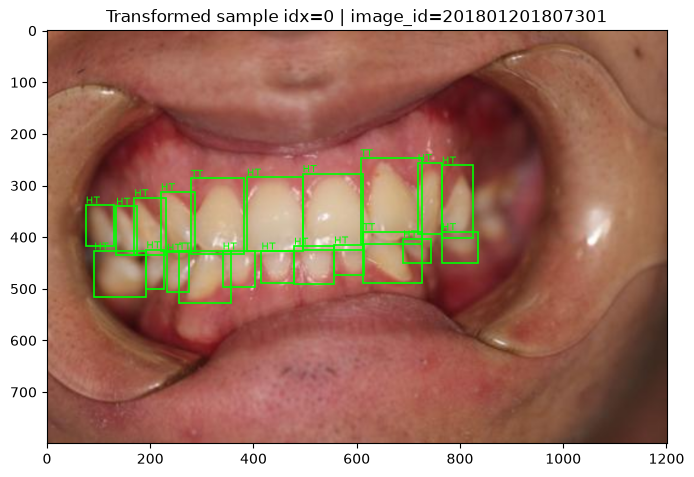

In [25]:
# visualisasi ulang setelah transform

def denormalize_for_display(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = image_tensor * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


def show_transformed_sample(dataset, idx):
    image, target = dataset[idx]
    img_np = denormalize_for_display(image)

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img_np)

    for box, label_id in zip(target["boxes"], target["labels"]):
        x_min, y_min, x_max, y_max = box.tolist()
        label_name = category_id_to_name[label_id.item()]
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=1.2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x_min, y_min - 3, label_name, color="lime", fontsize=7)

    plt.title(f"Transformed sample idx={idx} | image_id={target['image_id'].item()}")
    plt.show()


show_transformed_sample(train_dataset, 0)

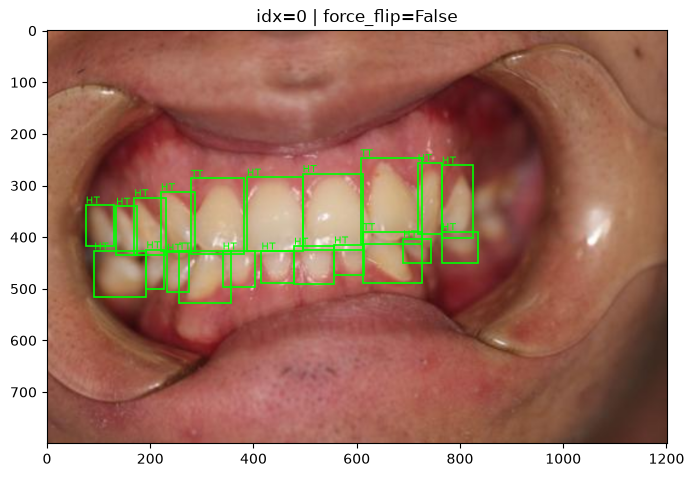

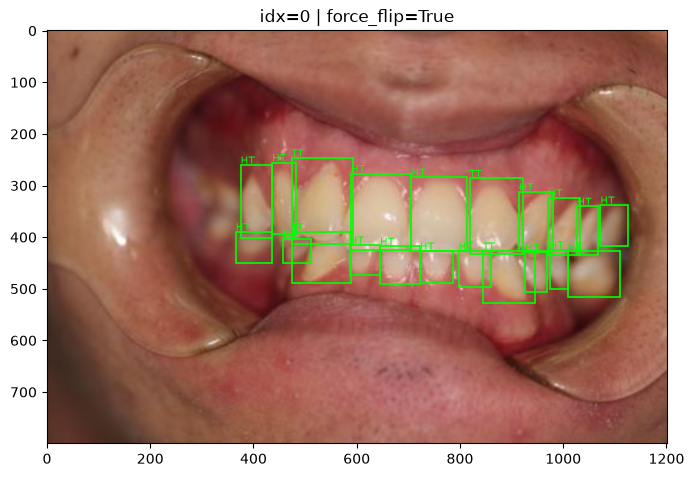

In [26]:
def show_transformed_sample_forced_flip(dataset, idx, force_flip: bool):
    img_record = dataset.images[idx]
    img_path = get_image_path(dataset.split, img_record)
    image = Image.open(img_path).convert("RGB")

    orig_w, orig_h = img_record["width"], img_record["height"]
    anns = image_to_anns[dataset.split].get(img_record["id"], [])

    boxes = []
    labels = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        boxes.append([x, y, x + w, y + h])
        labels.append(ann["category_id"])

    boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
    labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

    image, boxes, scale = resize_image_and_boxes(image, boxes, orig_w, orig_h)
    new_w = image.width

    if force_flip:
        image, boxes = horizontal_flip(image, boxes, new_w)

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(image)

    for box, label_id in zip(boxes, labels):
        x_min, y_min, x_max, y_max = box.tolist()
        label_name = category_id_to_name[label_id.item()]
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=1.2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x_min, y_min - 3, label_name, color="lime", fontsize=7)

    plt.title(f"idx={idx} | force_flip={force_flip}")
    plt.show()


# bandingkan langsung: tanpa flip vs dengan flip, gambar dan box yang sama
show_transformed_sample_forced_flip(train_dataset, 0, force_flip=False)
show_transformed_sample_forced_flip(train_dataset, 0, force_flip=True)

In [27]:
# data loader untuk tiap split

BATCH_SIZE = 2  # mulai kecil dulu, terutama kalau training di CPU/MPS

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,  # di macOS/MPS, num_workers>0 kadang bermasalah dengan multiprocessing; mulai dari 0 dulu
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 1241
val batches: 429
test batches: 414


In [28]:
# sanity check: ambil 1 batch dari train dataloader

images, targets = next(iter(train_loader))

print("Jumlah gambar dalam batch:", len(images))
for i, (img, tgt) in enumerate(zip(images, targets)):
    print(f"  sample {i}: image shape={img.shape}, jumlah box={tgt['boxes'].shape[0]}")

Jumlah gambar dalam batch: 2
  sample 0: image shape=torch.Size([3, 800, 1201]), jumlah box=11
  sample 1: image shape=torch.Size([3, 800, 1201]), jumlah box=12


## Section 3: Membangun / Memuat Model (Faster R-CNN)

Pakai `torchvision.models.detection.fasterrcnn_resnet50_fpn` (pretrained di COCO),
lalu ganti box_predictor supaya sesuai jumlah kelas OMNI (10 kelas + 1 background).
Termasuk device selection untuk Mac (MPS/CPU) dan sanity check forward pass.

In [29]:
# cek device

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Menggunakan device:", device)

Menggunakan device: mps


In [30]:
# class

# 10 kelas maloklusi (category_id 1..10) + 1 background (index 0)
NUM_CLASSES = len(category_id_to_name) + 1
print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 11


In [31]:
# Load model pretrained dan ganti box_predictor

def build_model(num_classes: int):
    # load Faster R-CNN pretrained di COCO (91 kelas)
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)

    # ganti head classifier supaya output sesuai jumlah kelas OMNI
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = build_model(NUM_CLASSES)
model.to(device)
print("Model berhasil dibangun dan dipindah ke", device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/benediktaaa/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 74.0MB/s] 


Model berhasil dibangun dan dipindah ke mps


In [32]:
# cek jumlah parameter

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameter: {total_params:,}")
print(f"Trainable parameter: {trainable_params:,}")

Total parameter: 41,345,286
Trainable parameter: 41,122,886


In [ ]:
# sanity check forward pass model train

model.train()

images, targets = next(iter(train_loader))
images = [img.to(device) for img in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

loss_dict = model(images, targets)
print("Loss dict keys:", loss_dict.keys())
for k, v in loss_dict.items():
    print(f"  {k}: {v.item():.4f}")

total_loss = sum(loss for loss in loss_dict.values())
print("Total loss:", total_loss.item())

Loss dict keys: dict_keys(['loss_classifier', 'loss_box_reg', 'loss_objectness', 'loss_rpn_box_reg'])
  loss_classifier: 2.6256
  loss_box_reg: 0.1463
  loss_objectness: 0.7843
  loss_rpn_box_reg: 0.1063
Total loss: 3.662475824356079


In [34]:
# sanity check forward pass model eval

model.eval()

with torch.no_grad():
    images, targets = next(iter(val_loader))
    images = [img.to(device) for img in images]
    predictions = model(images)

print("Jumlah prediksi:", len(predictions))
print("Contoh prediksi pertama:")
print("  boxes shape:", predictions[0]["boxes"].shape)
print("  labels:", predictions[0]["labels"])
print("  scores:", predictions[0]["scores"])

Jumlah prediksi: 2
Contoh prediksi pertama:
  boxes shape: torch.Size([100, 4])
  labels: tensor([8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 7, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 1, 1, 1, 3, 1,
        1, 1, 1, 1], device='mps:0')
  scores: tensor([0.3540, 0.2864, 0.2845, 0.2842, 0.2791, 0.2752, 0.2714, 0.2661, 0.2654,
        0.2620, 0.2603, 0.2562, 0.2542, 0.2534, 0.2530, 0.2527, 0.2525, 0.2525,
        0.2503, 0.2497, 0.2491, 0.2483, 0.2483, 0.2467, 0.2460, 0.2452, 0.2451,
        0.2444, 0.2441, 0.2436, 0.2433, 0.2426, 0.2422, 0.2420, 0.2413, 0.2404,
        0.2397, 0.2393, 0.2386, 0.2382, 0.2381, 0.2379, 0.2375, 0.2371, 0.2363,
        0.2363, 0.2362, 0.2357, 0.2356, 0.2339, 0.2339, 0.2339, 0.2338, 0.2336,
        0.2303, 0.2298, 0.2295, 0.2295, 0.2293, 0.2293, 0.2285,

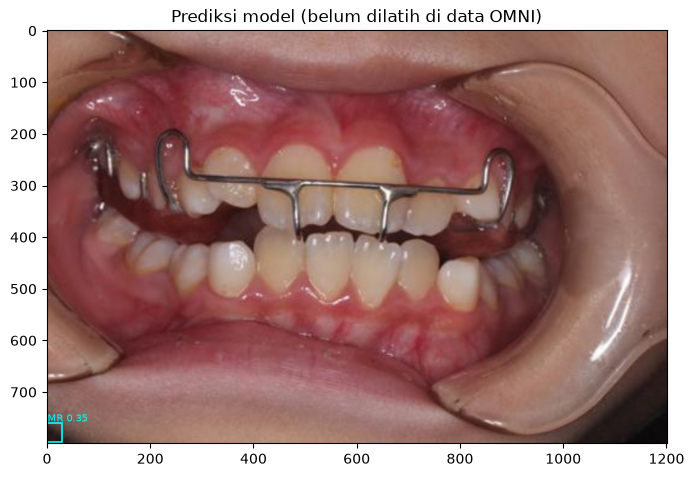

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [37]:
# Visualisasi prediksi awal (sebelum training, sekadar baseline sanity check)

def show_predictions(image_tensor, prediction, score_threshold=0.3):
    img_np = denormalize_for_display(image_tensor.cpu())

    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(img_np)

    boxes = prediction["boxes"].cpu()
    labels = prediction["labels"].cpu()
    scores = prediction["scores"].cpu()

    for box, label_id, score in zip(boxes, labels, scores):
        if score < score_threshold:
            continue
        x_min, y_min, x_max, y_max = box.tolist()
        label_name = category_id_to_name.get(label_id.item(), "unknown")
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=1.2, edgecolor="cyan", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x_min, y_min - 3, f"{label_name} {score:.2f}", color="cyan", fontsize=7)

    plt.title("Prediksi model (belum dilatih di data OMNI)")
    plt.show()


model.eval()
with torch.no_grad():
    show_predictions(images[0], predictions[0])
model.train()

## Section 4: Loss Function & Optimizer

Faster R-CNN dari torchvision sudah menghitung loss internal (tidak perlu ditulis manual).
Section ini fokus ke: memahami komponen loss, setup AdamW, dan scheduler
(LinearLR warm-up + MultiStepLR) sesuai konfigurasi di paper.

Faster R-CNN mengembalikan 4 komponen loss saat `model.train()`:

- `loss_classifier`  : cross-entropy, mengklasifikasikan tiap RoI ke salah satu dari 11 kelas (10 kelas OMNI + background)
- `loss_box_reg`     : Smooth L1, koreksi koordinat box hasil RoI Head (final refinement)
- `loss_objectness`  : binary cross-entropy, dari RPN, menilai apakah suatu region "ada objek" atau bukan (foreground vs background)
- `loss_rpn_box_reg` : Smooth L1, koreksi koordinat box dari RPN (region proposal awal)

Ini sesuai dengan Table II di paper untuk GraphTeethNet (Cross-entropy + Smooth L1),
tapi perlu dicatat: Faster R-CNN punya 2 tahap (RPN dan RoI Head), jadi total ada 4 loss,
bukan cuma 2 seperti yang ditulis sederhana di tabel paper.

In [38]:
# helper fungsi total loss

def compute_total_loss(loss_dict: dict) -> torch.Tensor:
    """
    Menjumlahkan semua komponen loss jadi satu scalar untuk di-backward.
    Torchvision Faster R-CNN sudah otomatis membagi lossnya per-kategori,
    training standar cukup menjumlahkan semua tanpa bobot tambahan
    (default: semua weight = 1.0).
    """
    return sum(loss for loss in loss_dict.values())

In [39]:
# setup optimizer dan scheduler

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

NUM_EPOCHS = 50  # sesuai paper untuk Faster R-CNN

WARMUP_EPOCHS = 1
MILESTONES = [30, 40]  # epoch di mana lr diturunkan, konvensi umum ~60% dan ~80% dari total epoch
GAMMA = 0.1  # lr dikali 0.1 tiap kali kena milestone

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.001,   # lr efektif di awal warm-up: 0.001 x LEARNING_RATE
    end_factor=1.0,       # menuju LEARNING_RATE penuh
    total_iters=WARMUP_EPOCHS,
)

main_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[m - WARMUP_EPOCHS for m in MILESTONES],  # geser karena warmup jalan duluan
    gamma=GAMMA,
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, main_scheduler],
    milestones=[WARMUP_EPOCHS],
)

print(optimizer)
print("Scheduler siap. Total epoch:", NUM_EPOCHS)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 1.0000000000000001e-07
    maximize: False
    weight_decay: 0.05
)
Scheduler siap. Total epoch: 50


/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:1194: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


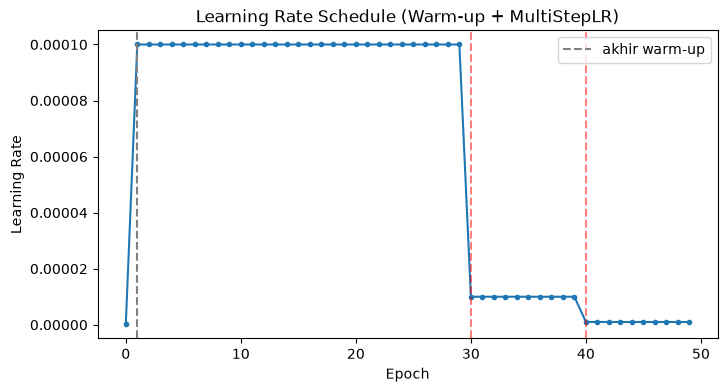

In [40]:
# sanity check

lr_history = []

# simulasi dummy: cuma panggil scheduler.step() tanpa training asli
dummy_optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
dummy_warmup = torch.optim.lr_scheduler.LinearLR(dummy_optimizer, start_factor=0.001, end_factor=1.0, total_iters=WARMUP_EPOCHS)
dummy_main = torch.optim.lr_scheduler.MultiStepLR(dummy_optimizer, milestones=[m - WARMUP_EPOCHS for m in MILESTONES], gamma=GAMMA)
dummy_scheduler = torch.optim.lr_scheduler.SequentialLR(dummy_optimizer, schedulers=[dummy_warmup, dummy_main], milestones=[WARMUP_EPOCHS])

for epoch in range(NUM_EPOCHS):
    lr_history.append(dummy_optimizer.param_groups[0]["lr"])
    dummy_scheduler.step()

plt.figure(figsize=(8, 4))
plt.plot(range(NUM_EPOCHS), lr_history, marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule (Warm-up + MultiStepLR)")
plt.axvline(WARMUP_EPOCHS, color="gray", linestyle="--", label="akhir warm-up")
for m in MILESTONES:
    plt.axvline(m, color="red", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

## Section 5: Training Loop

Loop per epoch, per batch, dengan tqdm untuk progress bar (loss real-time),
checkpoint model terbaik berdasarkan validation loss, dan logging history.

In [42]:
# train 1 epoch

def train_one_epoch(model, optimizer, data_loader, device, epoch_num):
    model.train()
    running_loss = 0.0
    loss_components = {"loss_classifier": 0.0, "loss_box_reg": 0.0, "loss_objectness": 0.0, "loss_rpn_box_reg": 0.0}

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch_num} [Train]", leave=True)

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        total_loss = compute_total_loss(loss_dict)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        for k in loss_components:
            loss_components[k] += loss_dict[k].item()

        # update progress bar dengan loss saat ini (running average)
        progress_bar.set_postfix({
            "loss": f"{running_loss / (progress_bar.n + 1):.4f}",
            "cls": f"{loss_dict['loss_classifier'].item():.3f}",
            "box": f"{loss_dict['loss_box_reg'].item():.3f}",
        })

    avg_loss = running_loss / len(data_loader)
    avg_components = {k: v / len(data_loader) for k, v in loss_components.items()}

    return avg_loss, avg_components

In [43]:
# val 1 epoch

def validate_one_epoch(model, data_loader, device, epoch_num):
    # trik: Faster R-CNN torchvision cuma return loss kalau model.train() DAN dikasih targets,
    # jadi untuk hitung val loss, kita tetap pakai model.train() tapi dengan torch.no_grad()
    # supaya tidak ada backward/update bobot.
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch_num} [Val]", leave=True)

    with torch.no_grad():
        for images, targets in progress_bar:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            total_loss = compute_total_loss(loss_dict)

            running_loss += total_loss.item()
            progress_bar.set_postfix({"val_loss": f"{running_loss / (progress_bar.n + 1):.4f}"})

    avg_loss = running_loss / len(data_loader)
    return avg_loss

In [ ]:
# training loop

history = {
    "train_loss": [],
    "val_loss": [],
}

best_val_loss = float("inf")
CHECKPOINT_PATH = "best_fasterrcnn_omni.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_components = train_one_epoch(model, optimizer, train_loader, device, epoch)
    val_loss = validate_one_epoch(model, val_loader, device, epoch)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    elapsed = time.time() - start_time
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"lr={current_lr:.6f} | time={elapsed:.1f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> Model terbaik disimpan (val_loss={val_loss:.4f})")

Epoch 1 [Train]:   0%|          | 0/1241 [00:00<?, ?it/s]

In [ ]:
# plot loss history

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Section 6: Evaluasi Model (mAP)

Load model terbaik dari checkpoint, jalankan inference di test set,
hitung mAP (IoU 0.5:0.95), mAP@0.5, mAP@0.75, dan breakdown per kategori
menggunakan torchmetrics, sesuai metrik yang dipakai di paper.

In [ ]:
# load model dari checkpoint terbaik

model = build_model(NUM_CLASSES)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()

print(f"Model berhasil di-load dari {CHECKPOINT_PATH}")

In [ ]:
# jalankan inference

def run_inference(model, data_loader, device):
    model.eval()
    all_predictions = []
    all_targets = []

    progress_bar = tqdm(data_loader, desc="Inference [Test]")

    with torch.no_grad():
        for images, targets in progress_bar:
            images = [img.to(device) for img in images]

            predictions = model(images)

            # pindahkan ke CPU untuk torchmetrics (lebih stabil dihitung di CPU)
            for pred in predictions:
                all_predictions.append({
                    "boxes": pred["boxes"].cpu(),
                    "scores": pred["scores"].cpu(),
                    "labels": pred["labels"].cpu(),
                })

            for tgt in targets:
                all_targets.append({
                    "boxes": tgt["boxes"].cpu(),
                    "labels": tgt["labels"].cpu(),
                })

    return all_predictions, all_targets


predictions, ground_truths = run_inference(model, test_loader, device)
print(f"Total sample dievaluasi: {len(predictions)}")

In [ ]:
# hitung mAP keseluruhan

metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox",
    class_metrics=True,  # supaya dapat breakdown per kategori juga
)

metric.update(predictions, ground_truths)
results = metric.compute()

print(f"mAP (0.5:0.95): {results['map'].item() * 100:.2f}")
print(f"mAP@0.5        : {results['map_50'].item() * 100:.2f}")
print(f"mAP@0.75       : {results['map_75'].item() * 100:.2f}")

In [ ]:
# breakdown mAP per kategori

per_class_ap = results["map_per_class"]  # tensor, urutan sesuai kelas yang muncul di data
class_ids_present = results["classes"]   # tensor berisi category_id yang ada di ground truth test set

df_per_class = pd.DataFrame({
    "category_id": class_ids_present.tolist(),
    "class_name": [category_id_to_name.get(c, "unknown") for c in class_ids_present.tolist()],
    "AP": (per_class_ap * 100).tolist(),
})
df_per_class = df_per_class.sort_values("AP", ascending=False)
print(df_per_class)

In [ ]:
# visualisasi perbandingan

plt.figure(figsize=(10, 5))
plt.bar(df_per_class["class_name"], df_per_class["AP"])
plt.xticks(rotation=45)
plt.ylabel("AP (%)")
plt.title("Average Precision per Kategori Maloklusi (Test Set)")
plt.tight_layout()
plt.show()


In [ ]:
# visualisasi prediksi vs ground truth untuk sample tertentu

def show_prediction_vs_gt(dataset, idx, model, device, score_threshold=0.5):
    image, target = dataset[idx]
    model.eval()

    with torch.no_grad():
        prediction = model([image.to(device)])[0]

    img_np = denormalize_for_display(image.cpu())

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ground truth
    axes[0].imshow(img_np)
    for box, label_id in zip(target["boxes"], target["labels"]):
        x_min, y_min, x_max, y_max = box.tolist()
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=1.2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x_min, y_min - 3, category_id_to_name[label_id.item()], color="lime", fontsize=7)
    axes[0].set_title("Ground Truth")

    # prediction
    axes[1].imshow(img_np)
    boxes, labels, scores = prediction["boxes"].cpu(), prediction["labels"].cpu(), prediction["scores"].cpu()
    for box, label_id, score in zip(boxes, labels, scores):
        if score < score_threshold:
            continue
        x_min, y_min, x_max, y_max = box.tolist()
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=1.2, edgecolor="cyan", facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x_min, y_min - 3, f"{category_id_to_name.get(label_id.item(),'?')} {score:.2f}", color="cyan", fontsize=7)
    axes[1].set_title(f"Prediksi (score>={score_threshold})")

    plt.tight_layout()
    plt.show()


show_prediction_vs_gt(test_dataset, 0, model, device)

In [ ]:
# simpan hasil

final_results = {
    "mAP": results["map"].item(),
    "mAP_50": results["map_50"].item(),
    "mAP_75": results["map_75"].item(),
    "per_class_AP": dict(zip(df_per_class["class_name"], df_per_class["AP"])),
}

with open("fasterrcnn_omni_eval_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("Hasil evaluasi disimpan ke fasterrcnn_omni_eval_results.json")